In [ ]:
import gc
import pathlib
import random
from typing import Dict, List, Sequence, Tuple, Union
import uuid

In [ ]:
try:
    import cupy as cp
except ImportError:
    import warnings

    warnings.warn(
        "cupy import failed; falling back to numpy "
        "(GPU engine unavailable)",
        stacklevel=2,
    )
    import numpy as cp

# workaround: iplotx 1.7.x uses importlib.metadata without importing it
import importlib.metadata  # noqa: F401

import downstream.dstream as dstream
import hstrat
import igraph as ig
import iplotx
import marimo as mo
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator
import numpy as np
import pandas as pd
from phyloframe import legacy as pfl
import polars as pl
import seaborn as sns
from teeplot import teeplot as tp
from tqdm.auto import tqdm
from watermark import watermark

from pylib import draw_scatter_tree

/usr/local/lib/python3.10/dist-packages/marimo/_runtime/executor.py:138: UserWarning: cupy import failed; falling back to numpy (GPU engine unavailable)
  exec(cell.body, glbls)


In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-05-03T19:29:25.404661+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

phyloframe: 0.8.1
matplotlib: 3.10.7
pandas    : 2.2.3
igraph    : 0.11.9
hstrat    : 1.25.0
marimo    : 0.23.2
downstream: 1.22.0
teeplot   : 1.4.2
polars    : 1.40.1
iplotx    : 1.7.1
seaborn   : 0.13.2
numpy     : 2.1.2

```

In [ ]:
# Marimo CLI args (set via `marimo edit notebook.py -- --pop-size N ...`
# or `marimo export ipynb ... -- --pop-size N ...`). Defaults match the
# current sweep settings: POP_SIZE=200_000 hosts and N_STEPS=100 steps.
_args = mo.cli_args()
POP_SIZE = int(_args.get("pop-size") or 200_000)
POW = float(_args.get("pow") or 1.0)
N_STEPS = int(_args.get("n-steps") or 100)
N_REPLICATES = int(_args.get("n-replicates") or 1)
ENGINE = str(_args.get("engine") or "numpy").lower()
if ENGINE not in ("numpy", "cupy"):
    raise ValueError(
        f"engine must be 'numpy' or 'cupy', got {ENGINE!r}",
    )
SKIP_PLOTTING = bool(_args.get("skip-plotting") or False)
print(
    f"args: POP_SIZE={POP_SIZE} N_STEPS={N_STEPS} "
    f"N_REPLICATES={N_REPLICATES} ENGINE={ENGINE} "
    f"SKIP_PLOTTING={SKIP_PLOTTING}",
)

args: POP_SIZE=200000 N_STEPS=100 N_REPLICATES=1 ENGINE=numpy SKIP_PLOTTING=False


In [ ]:
use_cupy = (
    ENGINE == "cupy"
)  # use cupy backend (GPU), otherwise numpy (CPU)
xp = [np, cp][use_cupy]

## Simulation Implementation

This notebook is a small-genome companion to
`2026-04-29-allele-abm-phylogeny-hstrat-32site.py`: the sweep is
restricted to `N_SITES = 2, 3, 4` so that per-strain prevalence and
per-strain population-average susceptibility can be tracked by
individual strain (the strain count is `2**N_SITES`, capped here at
16). In addition to the phylogeny-and-strain-network plots inherited
from the 32-site notebook, this notebook renders a "strain-curves"
figure: two vertically-stacked panels sharing the time axis, with
population susceptibility (dashed) on top and strain prevalence
(solid) on bottom, color-coded by strain.

Phylogeny estimation still uses *hereditary stratigraphic surface*
annotations (see https://hstrat.rtfd.io). Each infected host carries
a `dstream_S=64`-site, 1-bit "hybrid" surface; the donor surface
state is copied to the recipient on transmission (the ABM analogue
of `CloneDescendant`). Per-step Hamming-weight prevalence and
per-strain prevalence are both logged as long-form dataframes (one
row per `(Step, hw)` and `(Step, strain)`).

The vectorized deposit pattern is adapted from
https://github.com/mmore500/hstrat-synthesis (see `pylib/track_ca.py`).

In [ ]:
def simulate(
    N_SITES: int = 2,
    POP_SIZE: int = 1_000_000,
    CONTACT_RATE: float = 0.3,
    RECOVERY_RATE: float = 0.1,
    MUTATION_RATE: Union[float, Sequence[float]] = 1e-4,
    WANING_RATE: float = 0.02,
    IMMUNE_STRENGTH: float = 0.9,
    N_STEPS: int = 1_000,
    SEED_COUNT: int = 10,
    within_host_b: float = 0.2,
    within_host_t: float = 25.0,
    seed: int = 1,
    MUTATOR_HOSTS_N: int = 0,
    MUTATOR_HOSTS_MX: float = 1.0,
    MUTATION_THRESHOLD: float = 0.0,
    IMMUNITY_CEILING: float = 1.0,
    IMMUNITY_FLOOR: float = 0.0,
    track_phylogeny: bool = False,
    DSTREAM_S: int = 64,
    DSTREAM_ALGO=None,
    N_SAMPLE: int = 2000,
    pow: float = 1.0,
) -> Union[
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame],
    Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame],
]:
    random.seed(seed)
    np.random.seed(seed)
    xp.random.seed(seed)

    if DSTREAM_ALGO is None:
        DSTREAM_ALGO = dstream.hybrid_0_steady_1_tilted_2_algo

    MUTATION_RATE = xp.asarray(MUTATION_RATE, dtype=xp.float32)

    # Pick the smallest unsigned int dtype that holds `N_SITES` bits.
    # 16/32/64-site sweeps round-trip through uint16/uint32/uint64
    # without truncation; >64 would need a custom multi-word genome.
    if N_SITES > 64:
        raise NotImplementedError(
            "current data types support only up to 64 sites",
        )
    elif N_SITES > 32:
        genome_dtype = xp.uint64
    elif N_SITES > 16:
        genome_dtype = xp.uint32
    else:
        genome_dtype = xp.uint16

    def initialize_pop() -> (
        Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]
    ):
        """Initialize population statuses, genomes, and immune history."""
        pathogen_genomes = xp.zeros(shape=POP_SIZE, dtype=genome_dtype)
        host_immunities = xp.full(
            shape=(POP_SIZE, 2 * N_SITES),
            fill_value=0.0,
            dtype=xp.float32,
        )
        host_statuses = xp.full(
            shape=POP_SIZE, fill_value=0, dtype=xp.uint8
        )
        pathogen_markers = xp.random.randint(
            low=0,
            high=2**63,
            size=POP_SIZE,
            dtype=xp.int64,
        ).astype(xp.uint64)
        pathogen_markers |= xp.random.randint(
            low=0,
            high=2,
            size=POP_SIZE,
            dtype=xp.uint64,
        ) << xp.uint64(63)
        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )

    def infect_initial(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        """Seed the initial infection wave with the starting strain."""
        seeded_indices = xp.random.choice(
            POP_SIZE, size=SEED_COUNT, replace=False
        )
        host_statuses[seeded_indices] = 1
        pathogen_genomes[seeded_indices] = 0  # wildtype
        return host_statuses, pathogen_genomes

    def calc_infection_probabilities(
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> xp.ndarray:
        host_susceptibilities = xp.reshape(
            1.0 - (IMMUNE_STRENGTH * host_immunities),
            (POP_SIZE, 2 * N_SITES),
        )

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        active_susc = xp.where(
            pathogen_alleles, host_susceptibilities, 1.0
        )
        res = xp.prod(active_susc, axis=1)
        assert res.shape == (POP_SIZE,)
        return xp.pow(res, pow)

    if MUTATION_RATE.size == 1:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            pathogen_bits = (
                pathogen_genomes[:, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1

            imm_reshaped = xp.reshape(host_immunities, (-1, N_SITES, 2))

            idx_curr = pathogen_bits[:, :, None]
            idx_opp = 1 - idx_curr

            imm_curr = xp.take_along_axis(
                imm_reshaped, idx_curr, axis=2
            ).squeeze(axis=2)
            imm_opp = xp.take_along_axis(
                imm_reshaped, idx_opp, axis=2
            ).squeeze(axis=2)

            host_immunity_deltas = imm_curr - imm_opp

            b_values = 1.0 + within_host_b * host_immunity_deltas
            b_values = xp.where(
                xp.abs(b_values - 1.0) < 1e-7, 1.000001, b_values
            )

            return (MUTATION_RATE / (b_values - 1.0)) * (
                xp.exp((b_values - 1.0) * within_host_t) - 1.0
            )

    else:

        def calc_mutation_probabilities(
            host_immunities: xp.ndarray,
            pathogen_genomes: xp.ndarray,
        ) -> xp.ndarray:
            n_infected = host_immunities.shape[0]
            return (
                xp.ones((n_infected, 1), dtype=MUTATION_RATE.dtype)
                * MUTATION_RATE
            )

    def update_waning(host_immunities: xp.ndarray) -> xp.ndarray:
        host_immunities *= 1.0 - WANING_RATE
        host_immunities[host_immunities > 0] = xp.clip(
            host_immunities[host_immunities > 0],
            IMMUNITY_FLOOR,
            IMMUNITY_CEILING,
        )
        return host_immunities

    def update_recoveries(
        host_statuses: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_genomes: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray]:
        recovered_mask = (host_statuses >= 1) * xp.random.rand(
            POP_SIZE
        ) > 1 - RECOVERY_RATE

        pathogen_bits = (
            pathogen_genomes[:, None] >> xp.arange(N_SITES, dtype=xp.uint8)
        ) & 1
        pathogen_alleles = (
            pathogen_bits[:, :, None] == xp.array([0, 1])
        ).reshape(-1, 2 * N_SITES)

        assert np.all(
            pathogen_alleles[recovered_mask].sum(axis=1) == N_SITES
        )

        host_immunities[
            pathogen_alleles.astype(bool) & recovered_mask[:, None]
        ] = 1.0

        host_statuses += (host_statuses > 0).astype(xp.uint8)
        host_statuses[recovered_mask] = 0

        return host_statuses, host_immunities

    def transmit_infection(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray]:
        contacts = xp.random.randint(
            low=0, high=POP_SIZE, size=POP_SIZE, dtype=xp.uint32
        )
        inf_probs = (
            calc_infection_probabilities(
                host_immunities, pathogen_genomes[contacts]
            )
            * (host_statuses == 0)
            * (host_statuses[contacts] > 0)
            * CONTACT_RATE
        )

        new_infections = xp.random.rand(POP_SIZE) < inf_probs
        host_statuses[new_infections] = 1
        pathogen_genomes[new_infections] = pathogen_genomes[contacts][
            new_infections
        ]
        pathogen_markers[new_infections] = pathogen_markers[contacts][
            new_infections
        ]

        return host_statuses, pathogen_genomes, pathogen_markers

    def apply_mutations(
        pathogen_genomes: xp.ndarray,
        host_statuses: xp.ndarray,
    ) -> xp.ndarray:
        mutation_mask = (host_statuses == 1).astype(bool)

        mprobs = calc_mutation_probabilities(
            host_immunities[mutation_mask],
            pathogen_genomes[mutation_mask],
        )
        mutator_n = host_statuses[:MUTATOR_HOSTS_N].sum()
        mprobs[:mutator_n] = xp.minimum(
            mprobs[:mutator_n] * MUTATOR_HOSTS_MX, 1.0
        )

        mprobs[mprobs < MUTATION_THRESHOLD] = 0.0

        for s in range(N_SITES):
            mutation_occurs = (
                xp.random.rand(mprobs.shape[0]) < mprobs[:, s]
            ).astype(genome_dtype)
            pathogen_genomes[mutation_mask] ^= (
                mutation_occurs << s
            ).astype(genome_dtype)

        return pathogen_genomes

    def deposit_strata(
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> xp.ndarray:
        site = DSTREAM_ALGO.assign_storage_site(DSTREAM_S, t + DSTREAM_S)
        if site is None:
            return pathogen_markers
        new_bits = xp.random.randint(
            0,
            2,
            size=POP_SIZE,
            dtype=xp.uint64,
        )
        pathogen_markers ^= new_bits << np.uint64(63 - site)
        return pathogen_markers

    def update_simulation(
        host_statuses: xp.ndarray,
        pathogen_genomes: xp.ndarray,
        host_immunities: xp.ndarray,
        pathogen_markers: xp.ndarray,
        t: int,
    ) -> Tuple[xp.ndarray, xp.ndarray, xp.ndarray, xp.ndarray]:
        (
            host_statuses,
            pathogen_genomes,
            pathogen_markers,
        ) = transmit_infection(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )
        pathogen_genomes = apply_mutations(pathogen_genomes, host_statuses)
        host_statuses, host_immunities = update_recoveries(
            host_statuses, host_immunities, pathogen_genomes
        )
        host_immunities = update_waning(host_immunities)
        pathogen_markers = deposit_strata(pathogen_markers, t)

        return (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        )

    (
        host_statuses,
        pathogen_genomes,
        host_immunities,
        pathogen_markers,
    ) = initialize_pop()
    host_statuses, pathogen_genomes = infect_initial(
        host_statuses, pathogen_genomes
    )
    data_log: List[Dict[str, float]] = []
    hw_log: List[Dict[str, float]] = []
    strain_log: List[Dict[str, float]] = []
    n_strains = 1 << N_SITES

    for t in tqdm(range(N_STEPS), mininterval=20.0):
        (
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
        ) = update_simulation(
            host_statuses,
            pathogen_genomes,
            host_immunities,
            pathogen_markers,
            t,
        )

        inf_mask = host_statuses > 0
        hw_prevalences: List[float] = [0.0] * (N_SITES + 1)
        strain_prevalences: List[float] = [0.0] * n_strains

        if xp.any(inf_mask):
            infected_bits = (
                pathogen_genomes[inf_mask, None]
                >> xp.arange(N_SITES, dtype=xp.uint8)
            ) & 1
            hw_per_host = infected_bits.sum(axis=1).astype(xp.int64)
            hw_counts_arr = xp.bincount(hw_per_host, minlength=N_SITES + 1)
            hw_prevalences = [
                float(c) / POP_SIZE for c in hw_counts_arr.tolist()
            ]

            strain_per_host = pathogen_genomes[inf_mask].astype(xp.int64)
            strain_counts_arr = xp.bincount(
                strain_per_host, minlength=n_strains
            )
            strain_prevalences = [
                float(c) / POP_SIZE for c in strain_counts_arr.tolist()
            ]

        for w, count in enumerate(hw_prevalences):
            hw_log.append(
                {
                    "Step": t,
                    "Seed": seed,
                    "hw": w,
                    "count": count,
                }
            )

        for s, count in enumerate(strain_prevalences):
            strain_log.append(
                {
                    "Step": t,
                    "Seed": seed,
                    "strain": s,
                    "count": count,
                }
            )

        avg_susc = xp.mean(
            1.0 - (IMMUNE_STRENGTH * host_immunities), axis=0
        )

        immunity_dict = {}
        for i in range(2 * N_SITES):
            site = i // 2
            bit = i % 2
            immunity_dict[f"Susc_S{site}_B{bit}"] = float(avg_susc[i])

        log_entry = {
            "Step": t,
            "Seed": seed,
            "Total_Infected": float(xp.sum(inf_mask)) / POP_SIZE,
        }
        log_entry.update(immunity_dict)
        data_log.append(log_entry)

    df = pd.DataFrame(data_log).fillna(0).copy()
    hw_df = pd.DataFrame(hw_log)
    strain_df = pd.DataFrame(strain_log)
    if not track_phylogeny:
        return df, hw_df, strain_df

    algo_name = f"dstream.{DSTREAM_ALGO.__name__}"
    S = DSTREAM_S
    T_bitwidth = 32
    bitwidth = 1
    bytes_per_T = T_bitwidth // 8
    bytes_per_storage = S * bitwidth // 8
    bytes_per_row = bytes_per_T + bytes_per_storage
    empty_records = pd.DataFrame(
        {
            "data_hex": pd.Series([], dtype=str),
            "dstream_algo": pd.Series([], dtype=str),
            "dstream_storage_bitoffset": pd.Series([], dtype="int64"),
            "dstream_storage_bitwidth": pd.Series([], dtype="int64"),
            "dstream_T_bitoffset": pd.Series([], dtype="int64"),
            "dstream_T_bitwidth": pd.Series([], dtype="int64"),
            "dstream_S": pd.Series([], dtype="int64"),
            "extant": pd.Series([], dtype=bool),
            "snapshot_step": pd.Series([], dtype="int64"),
            "genome": pd.Series([], dtype="int64"),
            "taxon_id": pd.Series([], dtype="int64"),
        },
    )
    infected_idx = xp.where(host_statuses > 0)[0]
    n_inf = int(infected_idx.size)
    if n_inf == 0:
        return df, hw_df, strain_df, empty_records

    n_sample = min(N_SAMPLE, n_inf)
    sampled = (
        xp.random.choice(infected_idx, size=n_sample, replace=False)
        if n_sample < n_inf
        else infected_idx
    )

    # CUPY SUPPORT: Transfer to host if using GPU
    _to_np = (lambda a: np.asarray(a)) if xp is np else (lambda a: a.get())
    sampled_markers = _to_np(pathogen_markers[sampled])
    sampled_genomes = _to_np(pathogen_genomes[sampled])
    # Rank includes implicit predeposits
    sampled_steps = np.full(n_sample, N_STEPS + DSTREAM_S, dtype=np.uint32)
    sampled_taxon_ids = np.arange(n_sample, dtype=np.int64)

    T_bytes_hex = sampled_steps.astype(">u4").tobytes().hex()
    marker_bytes_hex = sampled_markers.astype(">u8").tobytes().hex()
    data_hex = [
        (
            T_bytes_hex[i * bytes_per_T * 2 : (i + 1) * bytes_per_T * 2]
            + marker_bytes_hex[
                i * bytes_per_storage * 2 : (i + 1) * bytes_per_storage * 2
            ]
        )
        for i in range(n_sample)
    ]

    records_df = pd.DataFrame(
        {
            "data_hex": data_hex,
            "dstream_algo": algo_name,
            "dstream_storage_bitoffset": bytes_per_T * 8,
            "dstream_storage_bitwidth": bytes_per_storage * 8,
            "dstream_T_bitoffset": 0,
            "dstream_T_bitwidth": T_bitwidth,
            "dstream_S": S,
            "extant": True,
            "snapshot_step": sampled_steps.astype(np.int64),
            "genome": sampled_genomes.astype(np.int64),
            "taxon_id": sampled_taxon_ids,
        }
    )
    assert all(len(h) == bytes_per_row * 2 for h in data_hex), (
        f"hex length mismatch (expected {bytes_per_row * 2}, "
        f"got {set(len(h) for h in data_hex)})"
    )
    del data_hex, T_bytes_hex, marker_bytes_hex
    gc.collect()
    return df, hw_df, strain_df, records_df

## Surface-Annotation Reconstruction

Given the snapshot records emitted by `simulate(..., track_phylogeny=
True)`, run `hstrat.dataframe.surface_unpack_reconstruct` followed by
`hstrat.dataframe.surface_postprocess_trie` to estimate the phylogenetic
tree. We use `AssignOriginTimeNodeRankTriePostprocessor(t0="dstream_S")`
so that origin times line up with simulation step numbers.

In [ ]:
def reconstruct_phylogeny(
    records_df: pd.DataFrame,
) -> pd.DataFrame:
    in_df = pl.from_pandas(records_df)
    post = hstrat.dataframe.surface_build_tree(
        in_df,
        trie_postprocessor=(
            hstrat.phylogenetic_inference.AssignOriginTimeNodeRankTriePostprocessor(
                t0="dstream_S",
            )
        ),
    ).to_pandas()
    gc.collect()
    for col in ("id", "ancestor_id"):
        if col in post.columns:
            post[col] = post[col].astype("int64")
    post["extant"] = post["extant"].fillna(False).astype(bool)
    for col in ("snapshot_step", "genome", "origin_time"):
        if col in post.columns:
            post[col] = pd.to_numeric(post[col], errors="coerce")
    return post

## Surface-Reconstructed Phylogeny

Sweep `N_SITES` over a few values and render the surface-reconstructed
phylogeny next to the absolute-prevalence and Hamming-weight stackplots.

In [ ]:
def make_phylogeny_plot(
    N_SITES: int,
    phylo_df,
    hw_df,
    phylogeny_df,
    max_tips: int = 10_000,
    seed: int = 0,
    palette: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    pruned_df = (
        pfl.alifestd_downsample_tips_uniform_asexual(
            phylogeny_df,
            n_downsample=max_tips,
            seed=0,
        )
        .pipe(pfl.alifestd_add_global_root, root_attrs={"origin_time": 0})
        .pipe(pfl.alifestd_collapse_unifurcations)
        .pipe(pfl.alifestd_try_add_ancestor_list_col)
        .pipe(pfl.alifestd_ladderize_asexual)
        .pipe(pfl.alifestd_assign_contiguous_ids)
    )
    assert pfl.alifestd_validate(pruned_df)
    print(f"  downsampled tree: {len(pruned_df)} nodes")
    print(f"  leaf count: {pfl.alifestd_count_leaf_nodes(pruned_df)}")

    pruned_df = pruned_df.assign(
        hw=pruned_df["genome"].map(
            lambda g: None if pd.isna(g) else bin(int(g)).count("1"),
        ),
    )
    pruned_df = pruned_df.assign(
        hw_label=pruned_df["hw"].map(
            lambda w: None if pd.isna(w) else f"HW {int(w)}"
        ),
    )

    hw_values = list(range(N_SITES + 1))
    hw_palette = sns.color_palette(palette, len(hw_values))

    present_hw = sorted(int(w) for w in hw_df["hw"].unique())
    hw_labels = [f"HW {w}" for w in present_hw]
    plot_df = hw_df.assign(
        y=-hw_df["Step"],
        hw_label=hw_df["hw"].map(lambda w: f"HW {int(w)}"),
    )
    plot_df = plot_df[plot_df["count"] > 0]

    if len(present_hw) > 4:
        _idx = np.unique(
            np.linspace(0, len(present_hw) - 1, 4).round().astype(int)
        ).tolist()
    else:
        _idx = list(range(len(present_hw)))
    hw_legend_entries = [(present_hw[i], hw_labels[i]) for i in _idx]

    def _hw_handle(w, label):
        return plt.Line2D(
            [0],
            [0],
            marker="s",
            color="w",
            markerfacecolor=hw_palette[w],
            markersize=10,
            label=label,
        )

    hw_palette_map = {f"HW {w}": hw_palette[w] for w in present_hw}

    with tp.teed(
        plt.subplots,
        nrows=1,
        ncols=3,
        figsize=(8, 6),
        gridspec_kw={
            "width_ratios": [1.4, 1.0, 1.0],
            "wspace": 0.1,
        },
        sharey=True,
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_tree, ax_strain, ax_hw = axes

        sns.histplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            binwidth=phylo_df["Step"].diff().min(),
            multiple="stack",
            stat="count",
            element="poly",
            palette=hw_palette_map,
            ax=ax_strain,
            fill=True,
            linewidth=0,
            legend=False,
        )
        _band_xs = [
            c.get_paths()[0].vertices[:, 0].max()
            for c in ax_strain.collections
            if c.get_paths()
        ]
        if _band_xs:
            _peak = max(_band_xs)
            _lo, _ = ax_strain.get_xlim()
            ax_strain.set_xlim(_lo, _peak * 1.05)

        sns.kdeplot(
            data=plot_df,
            y="y",
            hue="hw_label",
            hue_order=hw_labels,
            weights="count",
            multiple="fill",
            common_norm=True,
            cut=0,
            palette=hw_palette_map,
            ax=ax_hw,
            fill=True,
            linewidth=0,
            legend=False,
            bw_adjust=0.5,
        )

        for ax in (ax_strain, ax_hw):
            ax.set_xlabel("")
        ax_hw.set_xlim(0, 1)

        ax_tree.set_ylabel("step")
        ax_tree.tick_params(left=True, labelleft=True)
        for ax in (ax_strain, ax_hw):
            ax.tick_params(labelleft=False, left=False)
            ax.xaxis.tick_top()
            ax.xaxis.set_label_position("top")

        ax_tree.tick_params(bottom=False, labelbottom=False)
        sns.despine(ax=ax_strain, left=True, bottom=True, top=False)
        sns.despine(ax=ax_hw, left=True, bottom=True, top=False)

        ax_hw.legend(
            handles=[
                _hw_handle(w, label) for w, label in hw_legend_entries
            ],
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
        )

        draw_scatter_tree(
            pruned_df.reset_index(drop=True),
            ax=ax_tree,
            hue="hw_label",
            scatter_kws=dict(
                legend=False,
                palette=hw_palette_map,
            ),
            tree_kws=dict(
                edge_color="gray",
                edge_linewidth=0.7,
                edge_zorder=1,
                ladderize=True,
            ),
        )
        sns.despine(ax=ax_tree, top=True, right=True, bottom=True)
        ax_tree.set_ylim(ax_hw.get_ylim())
        ax_tree.set_aspect("auto")
        ax_tree.yaxis.set_major_locator(MaxNLocator(integer=True))
        ax_tree.yaxis.set_major_formatter(
            FuncFormatter(lambda x, _: f"{abs(int(round(x)))}"),
        )

In [ ]:
def make_strain_graph_plot(
    N_SITES: int,
    records_df,
    max_n: int = 4,
    palette: str = "rocket_r",
    teeplot_outattrs: dict = {},
) -> None:
    """Plot final-step strains as undirected graphs at thresholds n=1..max_n.

    Nodes are unique strains (sized by population copies, colored by
    Hamming weight, 80% alpha). Edges connect strains within Hamming
    distance ``n``. For ``n > 1`` only edges that are not implicitly
    present via a 2-hop path through previously-added edges are drawn,
    with line thickness encoding the threshold ``n`` at which the edge
    was introduced.
    """
    extant = records_df[records_df["extant"]].copy()
    if len(extant) == 0:
        print("  (no extant records --- skipping strain graph plot)")
        return

    genomes = extant["genome"].astype("int64").to_numpy()
    strains, counts = np.unique(genomes, return_counts=True)
    n_strains = int(strains.size)
    if n_strains < 2:
        print(
            f"  (only {n_strains} strain --- skipping strain graph plot)"
        )
        return

    hamming_weights = np.array(
        [bin(int(s)).count("1") for s in strains], dtype=int
    )

    xor = strains[:, None] ^ strains[None, :]
    dists = np.zeros_like(xor, dtype=np.int32)
    tmp = xor.copy()
    while tmp.any():
        dists += (tmp & 1).astype(np.int32)
        tmp >>= 1

    cumulative = {}  # (i, j) with i < j -> threshold n at which added
    adjacency = [set() for _ in range(n_strains)]
    snapshots = []
    for n in range(1, max_n + 1):
        iu, ju = np.where(np.triu(dists == n, k=1))
        for i, j in zip(iu.tolist(), ju.tolist()):
            if n > 1 and adjacency[i] & adjacency[j]:
                continue
            cumulative[(i, j)] = n
            adjacency[i].add(j)
            adjacency[j].add(i)
        snapshots.append((n, dict(cumulative)))

    palette_colors = sns.color_palette(palette, N_SITES + 1)
    node_facecolors = [
        (*palette_colors[int(hw)], 0.8) for hw in hamming_weights
    ]

    max_count = int(counts.max())
    sizes = 4.0 + 18.0 * np.sqrt(counts / max_count)

    # Label only the dominant strains: those carrying more than 10% of
    # the sampled population, annotated with their Hamming weight.
    total = int(counts.sum())
    vertex_labels = [
        str(int(hamming_weights[i])) if counts[i] > 0.10 * total else ""
        for i in range(n_strains)
    ]

    # Layout: kamada_kawai on the densest graph (max_n) so vertex
    # positions are stable across subplots.
    ref_graph = ig.Graph(n=n_strains)
    ref_graph.add_edges(list(cumulative.keys()))
    if ref_graph.ecount() > 0:
        try:
            layout = ref_graph.layout_kamada_kawai()
        except Exception:
            layout = ref_graph.layout_fruchterman_reingold()
    else:
        layout = ref_graph.layout_circle()
    layout_coords = [tuple(c) for c in layout.coords]

    with tp.teed(
        plt.subplots,
        nrows=1,
        ncols=max_n,
        figsize=(4.5 * max_n, 4.5),
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        if max_n == 1:
            axes = [axes]

        for ax, (n, edges_dict) in zip(axes, snapshots):
            edges = list(edges_dict.keys())
            # 1-hop edges thickest, with progressively thinner widths
            # for higher-n edges; n>1 edges drawn dashed to distinguish
            # them from direct mutational neighbors.
            widths = [3.0 / edges_dict[e] for e in edges]
            linestyles = [
                "-" if edges_dict[e] == 1 else "--" for e in edges
            ]

            g_plot = ig.Graph(n=n_strains)
            if edges:
                g_plot.add_edges(edges)

            iplotx.network(
                g_plot,
                layout=layout_coords,
                vertex_facecolor=node_facecolors,
                vertex_edgecolor="black",
                vertex_size=sizes.tolist(),
                vertex_labels=vertex_labels,
                vertex_label_color="black",
                vertex_label_size=8,
                edge_linewidth=widths if widths else 1.0,
                edge_linestyle=linestyles if linestyles else "-",
                edge_color="gray",
                ax=ax,
                show=False,
            )
            ax.set_title(f"n = {n}")
            ax.set_aspect("equal")

        # Match make_phylogeny_plot's legend: span the same HW limits
        # (min/max of present Hamming weights), with up to 4
        # evenly-spaced entries.
        present_hw = sorted(int(w) for w in set(hamming_weights.tolist()))
        if len(present_hw) > 4:
            idx = np.unique(
                np.linspace(0, len(present_hw) - 1, 4).round().astype(int)
            ).tolist()
            legend_hw = [present_hw[i] for i in idx]
        else:
            legend_hw = present_hw

        handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markerfacecolor=(*palette_colors[w], 0.8),
                markeredgecolor="black",
                markersize=10,
                label=f"HW {w}",
            )
            for w in legend_hw
        ]
        axes[-1].legend(
            handles=handles,
            title="Hamming weight",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
        )

In [ ]:
def make_strain_curves_plot(
    N_SITES: int,
    traj_df,
    strain_df,
    palette: str = "tab10",
    teeplot_outattrs: dict = {},
) -> None:
    """Two-panel stacked figure: top = per-strain population-average
    susceptibility (dashed), bottom = per-strain prevalence (solid).
    Strains are color-coded; the time axis is shared between panels.
    """
    n_strains = 1 << N_SITES
    steps = traj_df["Step"].to_numpy()

    susc_by_site_bit = np.empty((len(traj_df), N_SITES, 2), dtype=float)
    for site in range(N_SITES):
        for bit in range(2):
            susc_by_site_bit[:, site, bit] = traj_df[
                f"Susc_S{site}_B{bit}"
            ].to_numpy()

    # Susceptibility to strain s = product over sites of Susc_S{site}_B{bit}
    # where `bit` is the allele of strain s at that site.
    susc_per_strain = np.ones((len(traj_df), n_strains), dtype=float)
    for s in range(n_strains):
        for site in range(N_SITES):
            bit = (s >> site) & 1
            susc_per_strain[:, s] *= susc_by_site_bit[:, site, bit]

    palette_colors = sns.color_palette(palette, n_strains)

    with tp.teed(
        plt.subplots,
        nrows=2,
        ncols=1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"hspace": 0.05},
        teeplot_outattrs=teeplot_outattrs,
        teeplot_show=True,
        teeplot_subdir=pathlib.Path(__file__).stem,
    ) as (fig, axes):
        ax_susc, ax_prev = axes

        for s in range(n_strains):
            color = palette_colors[s]
            label = f"{s:0{N_SITES}b}"
            ax_susc.plot(
                steps,
                susc_per_strain[:, s],
                color=color,
                linestyle="--",
                linewidth=1.5,
                label=label,
            )

            strain_s = strain_df[strain_df["strain"] == s]
            strain_s = strain_s.sort_values("Step")
            ax_prev.plot(
                strain_s["Step"].to_numpy(),
                strain_s["count"].to_numpy(),
                color=color,
                linestyle="-",
                linewidth=1.5,
                label=label,
            )

        ax_susc.set_ylabel("avg susceptibility")
        ax_susc.set_ylim(0.0, 1.0)
        ax_prev.set_ylabel("prevalence")
        ax_prev.set_xlabel("step")
        ax_prev.set_ylim(bottom=0.0)

        ax_susc.legend(
            title="strain",
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            frameon=False,
            handletextpad=0.4,
            ncol=1 if n_strains <= 8 else 2,
            fontsize=8,
        )
        sns.despine(ax=ax_susc)
        sns.despine(ax=ax_prev)

=== seed=1 N_SITES=2 uid=503e4175e0e941599904d2754b64aec0 ===


100%|██████████| 100/100 [00:04<00:00, 22.54it/s]


  snapshot rows: 200
  wrote traj parquet (100 rows): outdata/2026-05-03-allele-abm-strain-curves/traj/503e4175e0e941599904d2754b64aec0/a=traj+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote hw parquet (300 rows): outdata/2026-05-03-allele-abm-strain-curves/hw/503e4175e0e941599904d2754b64aec0/a=hw+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote strain parquet (400 rows): outdata/2026-05-03-allele-abm-strain-curves/strain/503e4175e0e941599904d2754b64aec0/a=strain+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote records parquet (200 rows): outdata/2026-05-03-allele-abm-strain-curves/records/503e4175e0e941599904d2754b64aec0/a=records+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


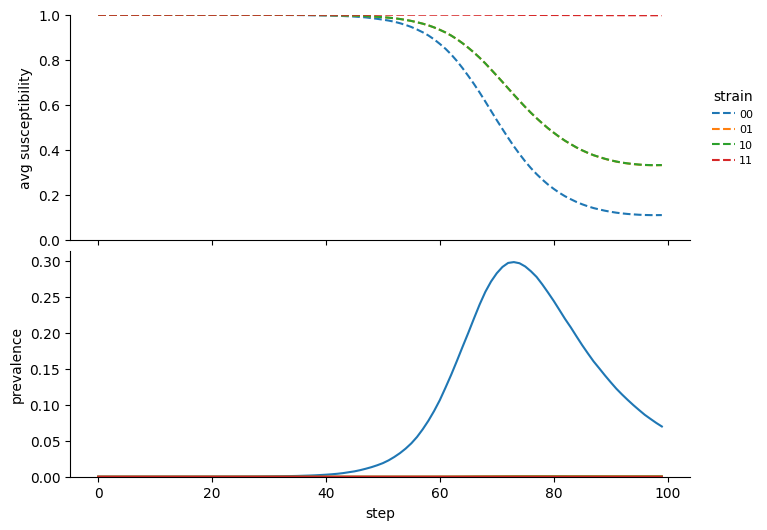

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


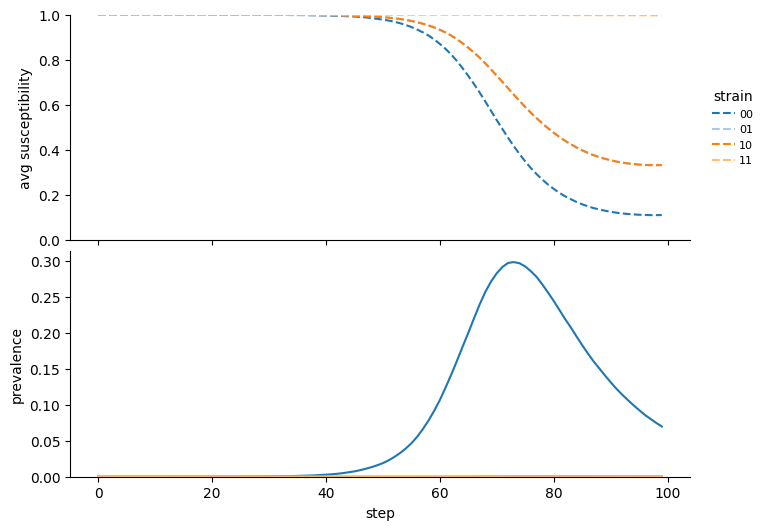

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


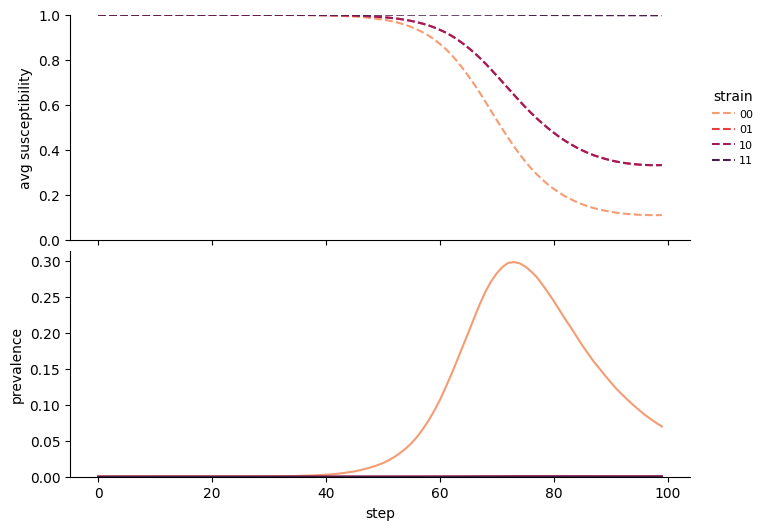

  extant rows: 200
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


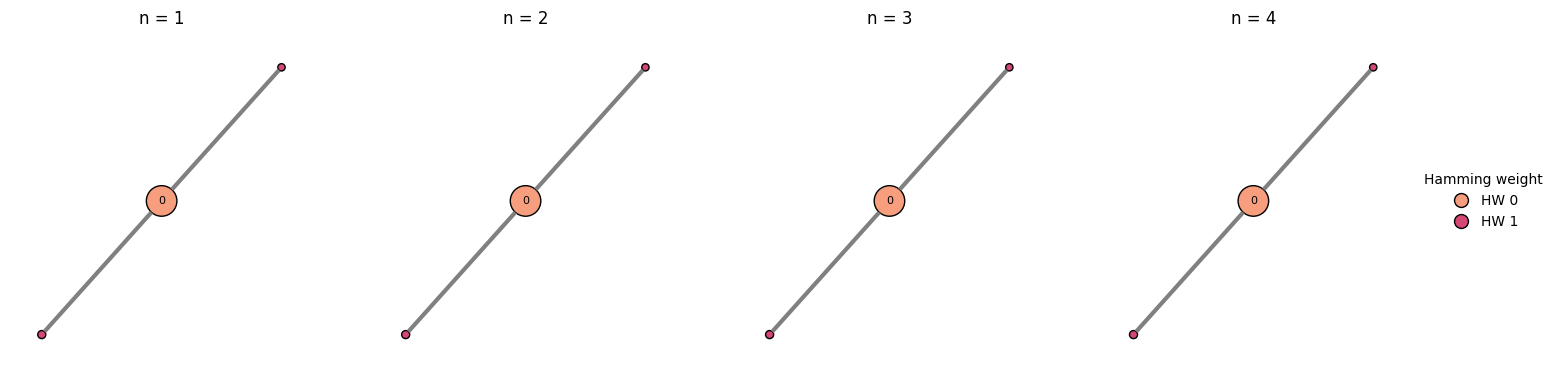

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


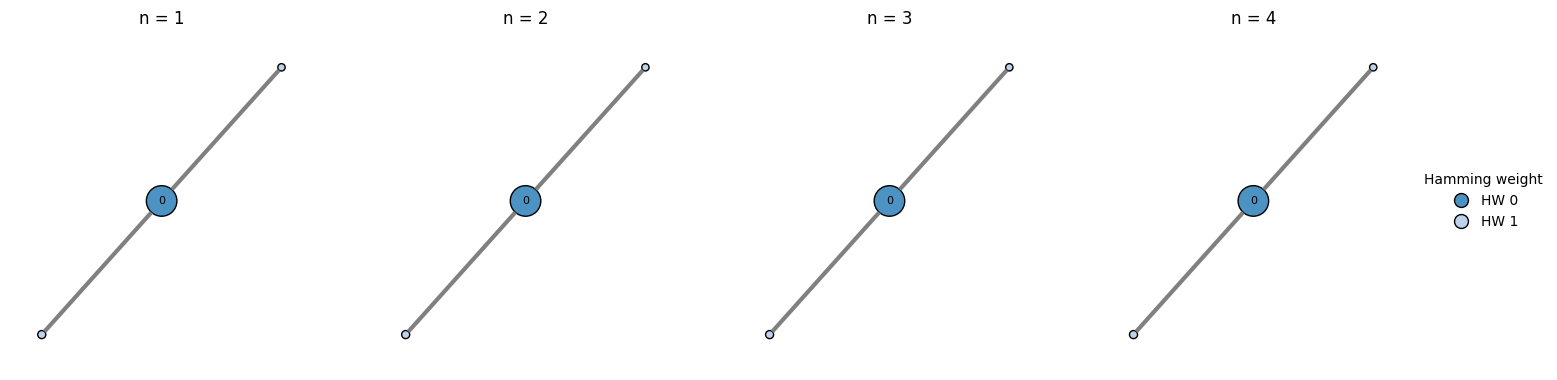

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


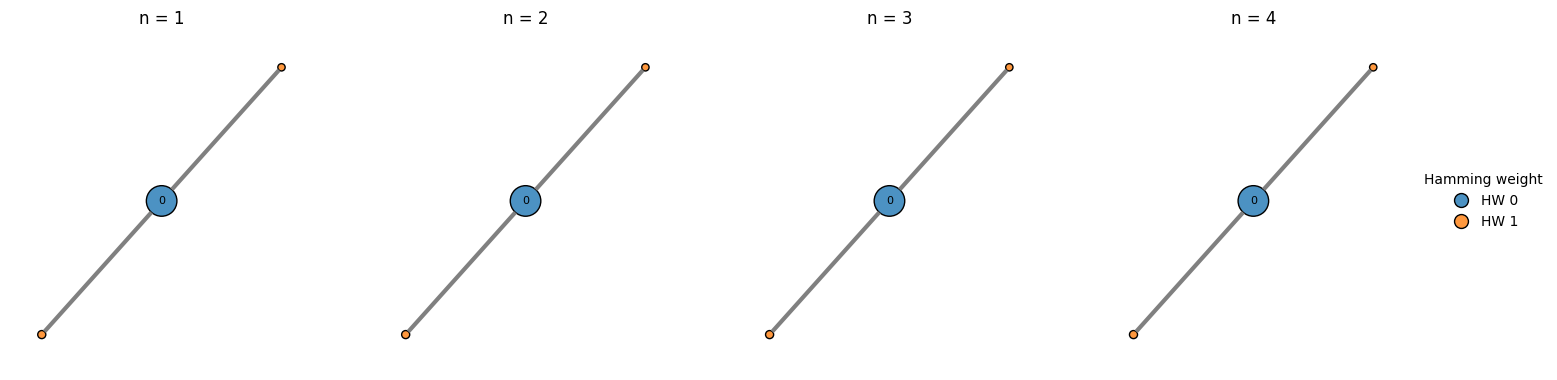

/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/alifedata_phyloinformatics_convert/_impl/phytrack_Systematcs.py:7: UserWarning: ImportWarning: phylotrackpy.Systematics import failed; inserting a no-op mock for Systematics. This is likely because phylotrackpy is not installed.
  warnings.warn(
2026-05-03 19:29:39 INFO     - worker collecting slice(0, 1000000, None)
2026-05-03 19:29:39 INFO     - worker exploding slice(0, 1000000, None)
2026-05-03 19:29:39 INFO     enter log_context_duration for dstream.dataframe.explode_lookup_unpacked (slice(0, 1000000, None))
/usr/local/lib/python3.10/dist-packages/downstream/dataframe/_impl/_check_downstream_version.py:34: UserWarning: Dataframe downstream_version column not pr

  reconstructed: 399 nodes
  extant tips: 200
  wrote phylo parquet (399 rows): outdata/2026-05-03-allele-abm-strain-curves/phylo/503e4175e0e941599904d2754b64aec0/a=phylo+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  downsampled tree: 400 nodes
  leaf count: 200


/tmp/marimo_4813/__marimo__cell_Kclp_.py:112: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


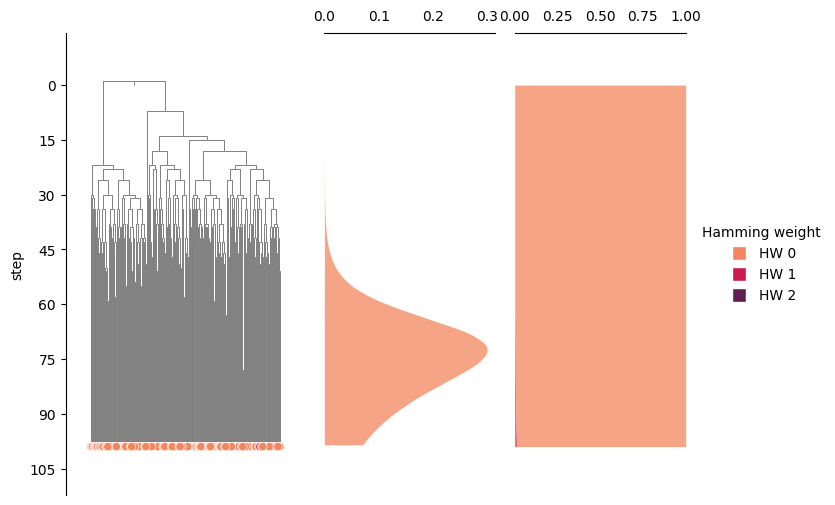

  downsampled tree: 400 nodes
  leaf count: 200


/tmp/marimo_4813/__marimo__cell_Kclp_.py:112: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


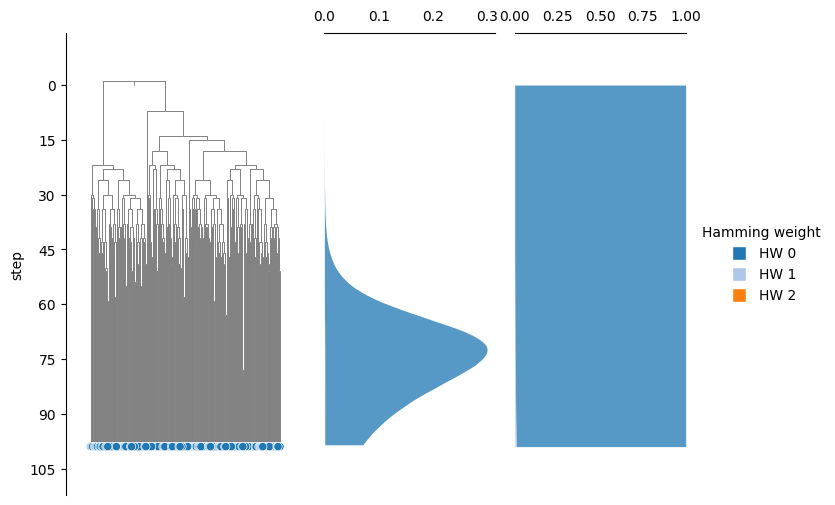

  downsampled tree: 400 nodes
  leaf count: 200


/tmp/marimo_4813/__marimo__cell_Kclp_.py:112: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=2+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


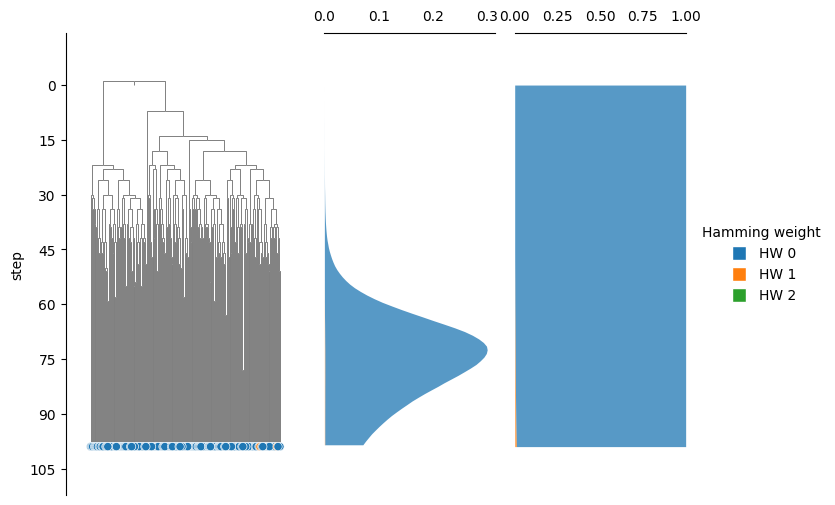

=== seed=1 N_SITES=3 uid=b3df08b4403c4f47a6a87c6ea18f1899 ===


100%|██████████| 100/100 [00:04<00:00, 20.43it/s]


  snapshot rows: 200
  wrote traj parquet (100 rows): outdata/2026-05-03-allele-abm-strain-curves/traj/b3df08b4403c4f47a6a87c6ea18f1899/a=traj+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote hw parquet (400 rows): outdata/2026-05-03-allele-abm-strain-curves/hw/b3df08b4403c4f47a6a87c6ea18f1899/a=hw+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote strain parquet (800 rows): outdata/2026-05-03-allele-abm-strain-curves/strain/b3df08b4403c4f47a6a87c6ea18f1899/a=strain+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote records parquet (200 rows): outdata/2026-05-03-allele-abm-strain-curves/records/b3df08b4403c4f47a6a87c6ea18f1899/a=records+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


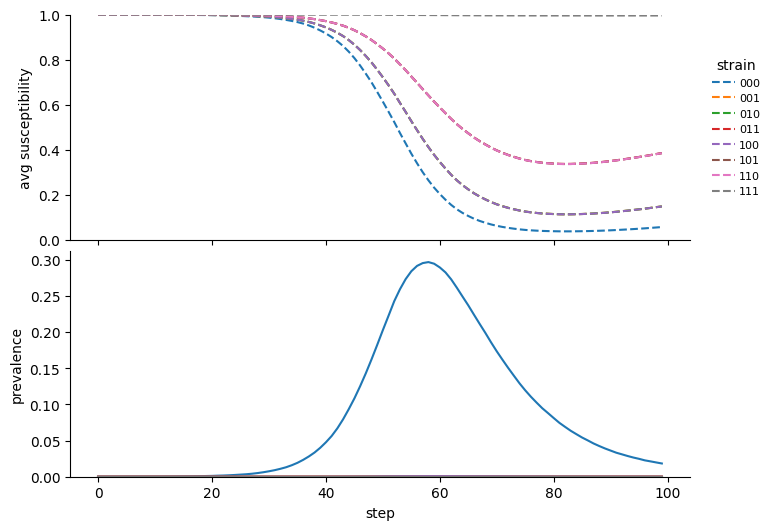

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


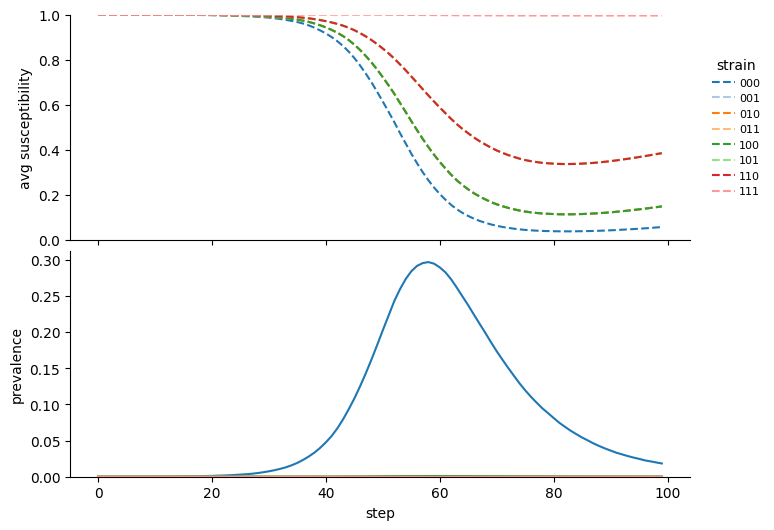

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


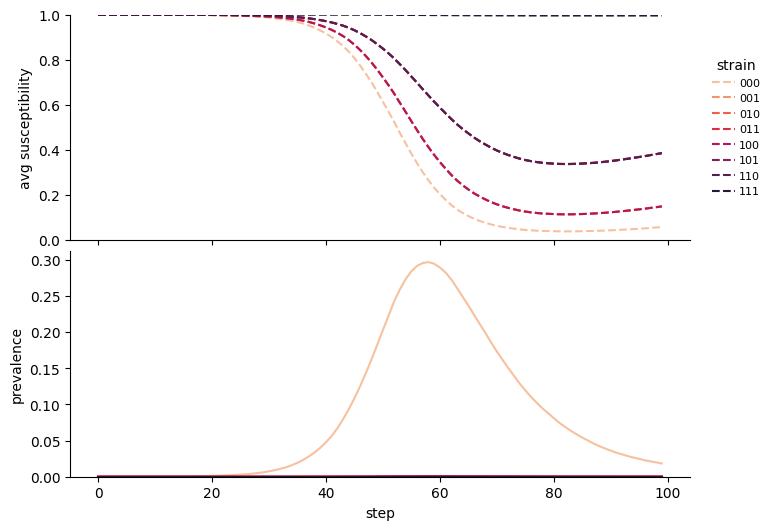

  extant rows: 200
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


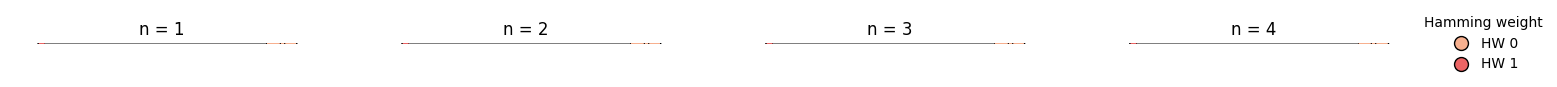

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


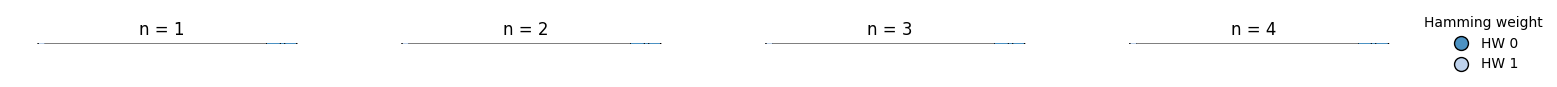

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


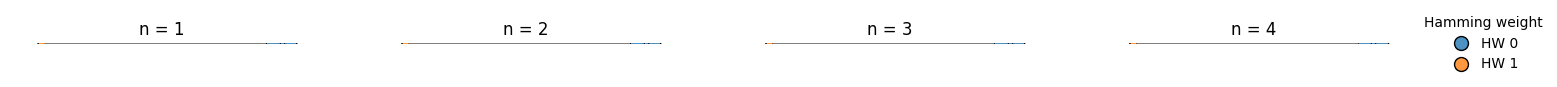

100%|██████████| 200/200 [00:00<00:00, 327168.80it/s]
/usr/local/lib/python3.10/dist-packages/hstrat/dataframe/_surface_postprocess_trie.py:139: UserWarning: CI environment detected, performing extra validation tests
  warnings.warn(
/tmp/marimo_4813/__marimo__cell_BYtC_.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post["extant"] = post["extant"].fillna(False).astype(bool)


  reconstructed: 398 nodes
  extant tips: 200
  wrote phylo parquet (398 rows): outdata/2026-05-03-allele-abm-strain-curves/phylo/b3df08b4403c4f47a6a87c6ea18f1899/a=phylo+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


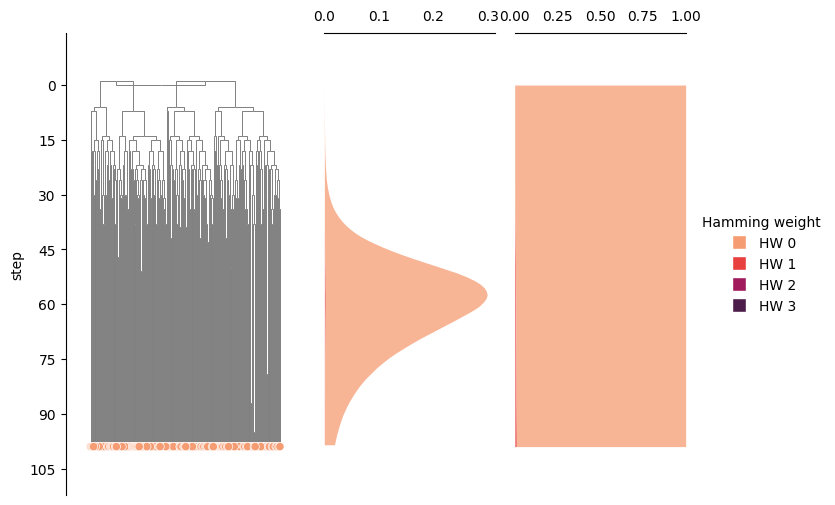

  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


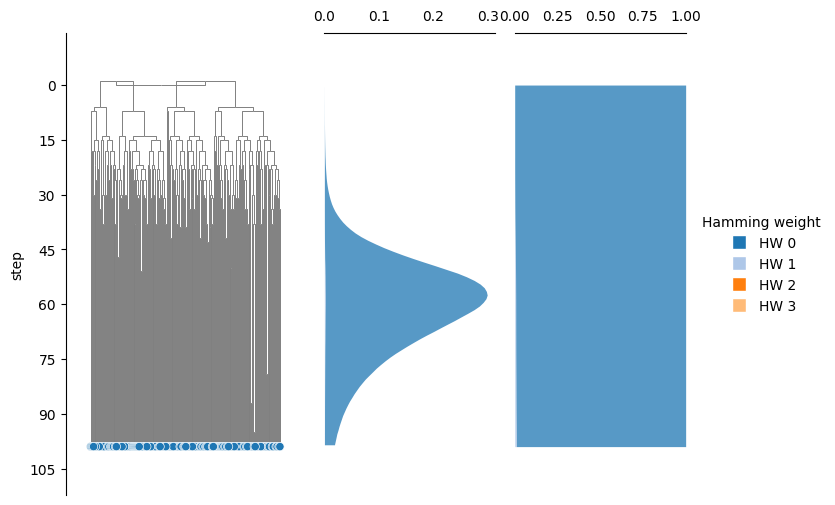

  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=3+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


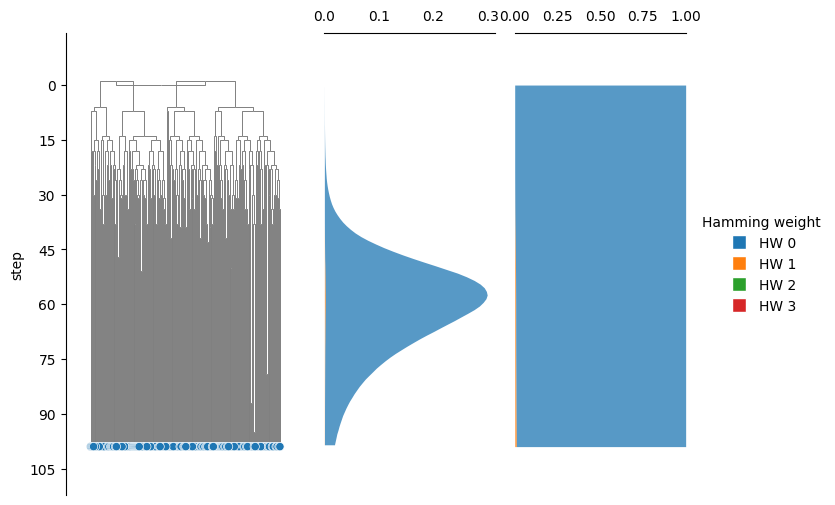

=== seed=1 N_SITES=4 uid=6f256ecc1bca40cf8c175f4a6a7f282e ===


100%|██████████| 100/100 [00:05<00:00, 17.58it/s]


  snapshot rows: 200
  wrote traj parquet (100 rows): outdata/2026-05-03-allele-abm-strain-curves/traj/6f256ecc1bca40cf8c175f4a6a7f282e/a=traj+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote hw parquet (500 rows): outdata/2026-05-03-allele-abm-strain-curves/hw/6f256ecc1bca40cf8c175f4a6a7f282e/a=hw+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote strain parquet (1600 rows): outdata/2026-05-03-allele-abm-strain-curves/strain/6f256ecc1bca40cf8c175f4a6a7f282e/a=strain+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  wrote records parquet (200 rows): outdata/2026-05-03-allele-abm-strain-curves/records/6f256ecc1bca40cf8c175f4a6a7f282e/a=records+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


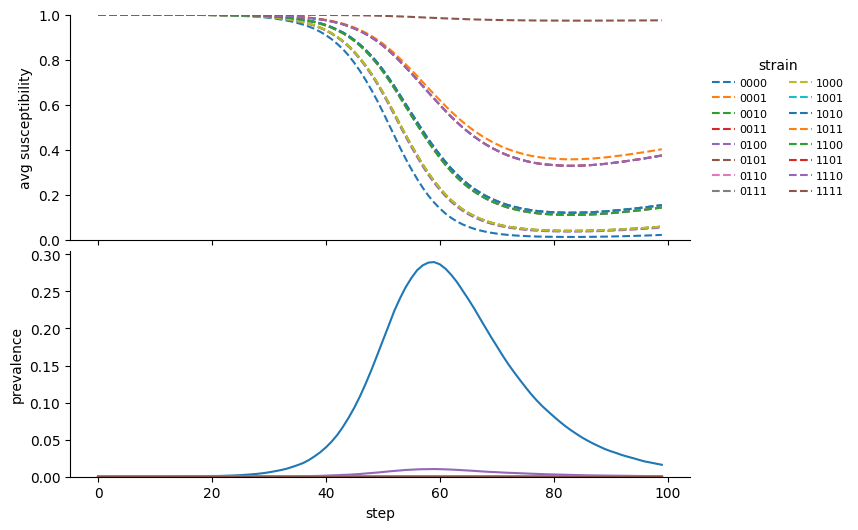

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


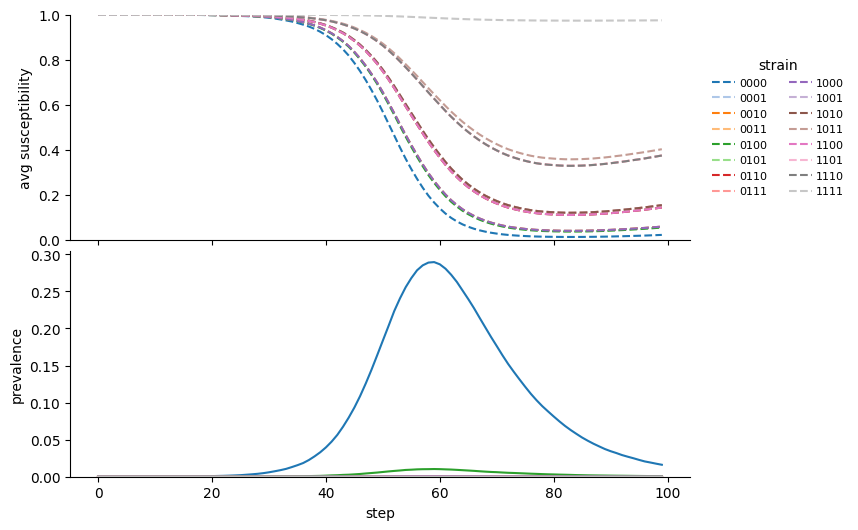

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-curves+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


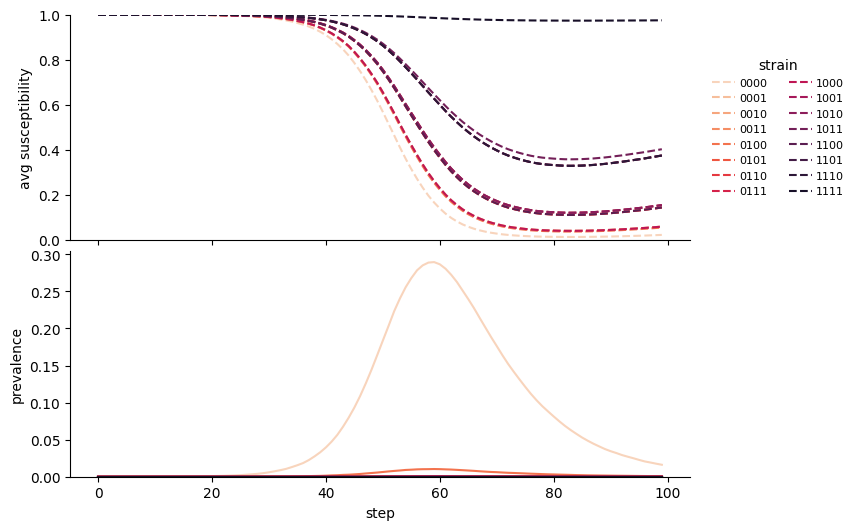

  extant rows: 200
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


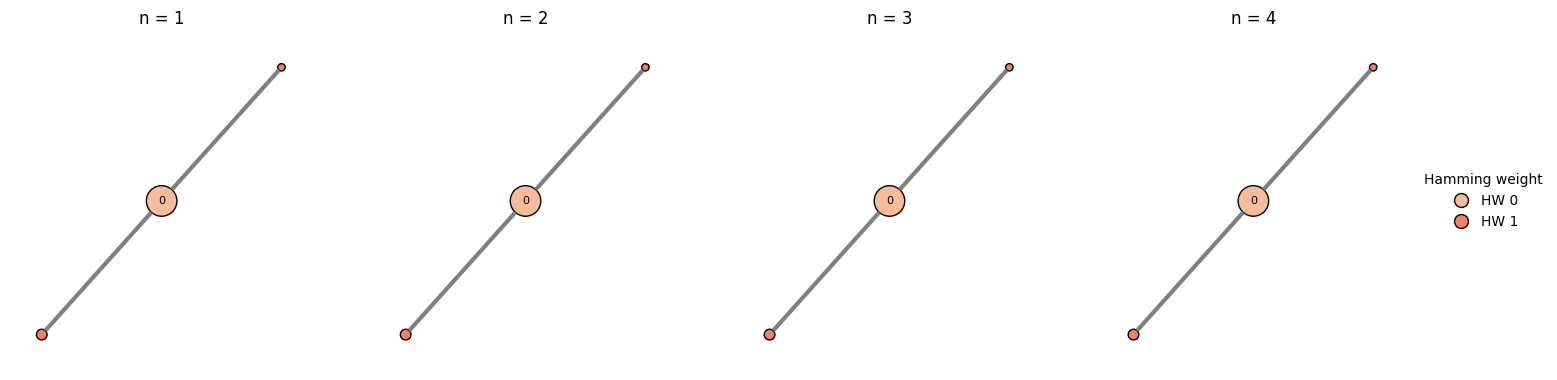

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


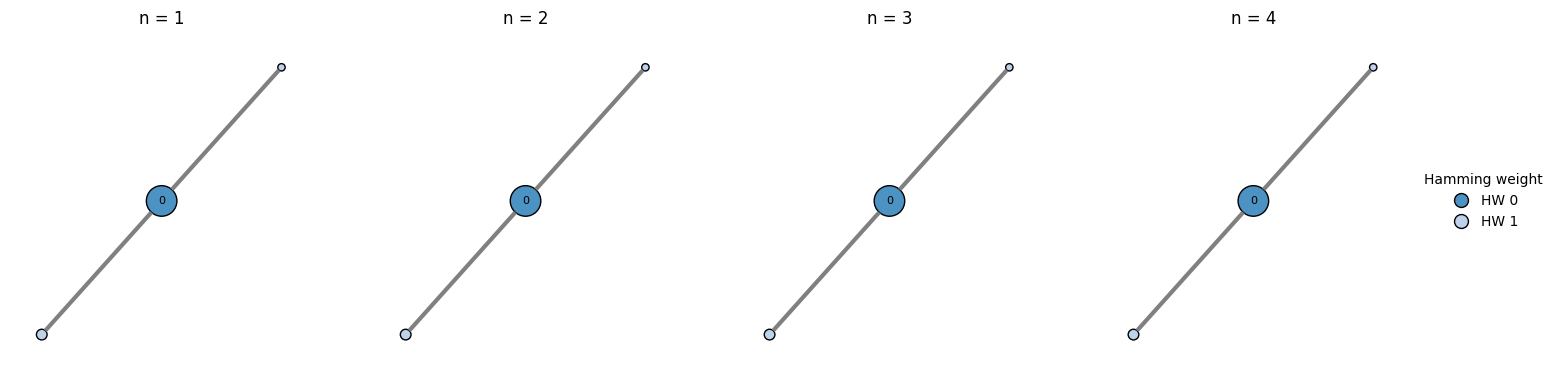

teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/a=strain-graph+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


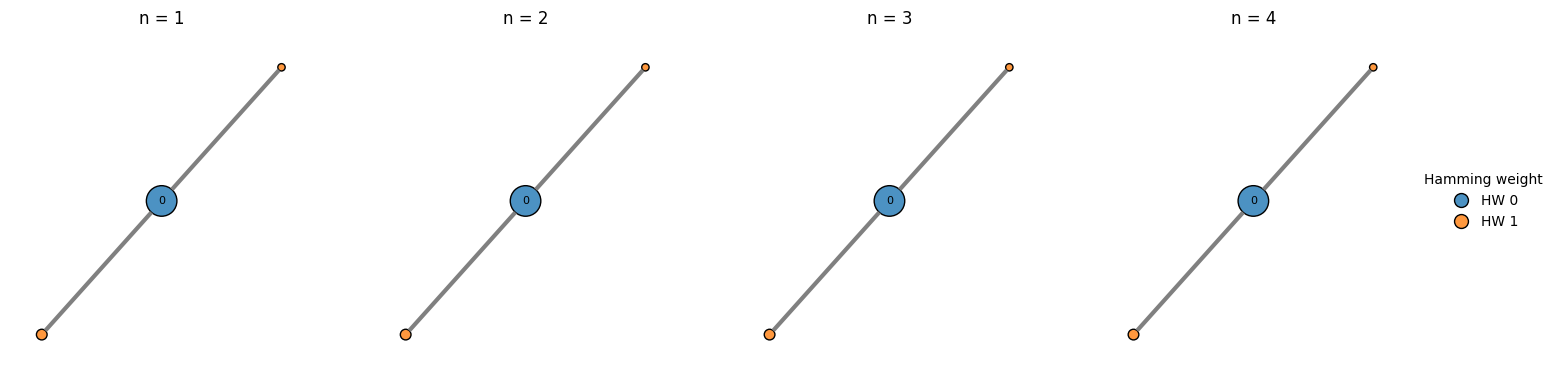

100%|██████████| 200/200 [00:00<00:00, 295061.84it/s]
/usr/local/lib/python3.10/dist-packages/hstrat/dataframe/_surface_postprocess_trie.py:139: UserWarning: CI environment detected, performing extra validation tests
  warnings.warn(
/tmp/marimo_4813/__marimo__cell_BYtC_.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  post["extant"] = post["extant"].fillna(False).astype(bool)


  reconstructed: 399 nodes
  extant tips: 200
  wrote phylo parquet (399 rows): outdata/2026-05-03-allele-abm-strain-curves/phylo/6f256ecc1bca40cf8c175f4a6a7f282e/a=phylo+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=rocket_r+pow=1.0+replicate=1+viz=subplots+ext=.png


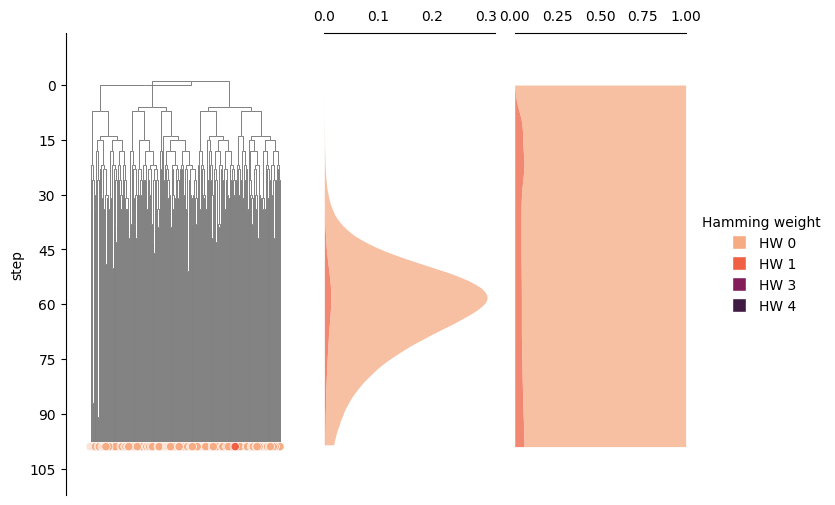

  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=tab20+pow=1.0+replicate=1+viz=subplots+ext=.png


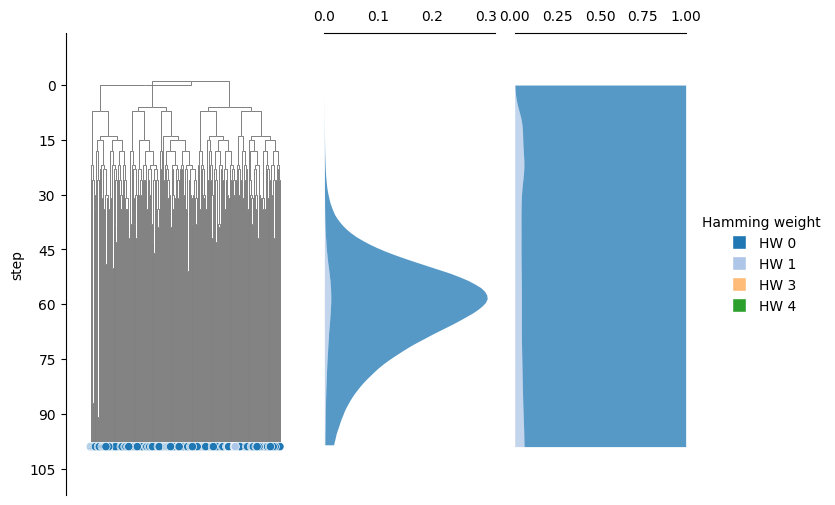

  downsampled tree: 399 nodes
  leaf count: 200
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.pdf
teeplots/2026-05-03-allele-abm-strain-curves/method=hstrat-surface+n_sites=4+n_steps=100+palette=tab10+pow=1.0+replicate=1+viz=subplots+ext=.png


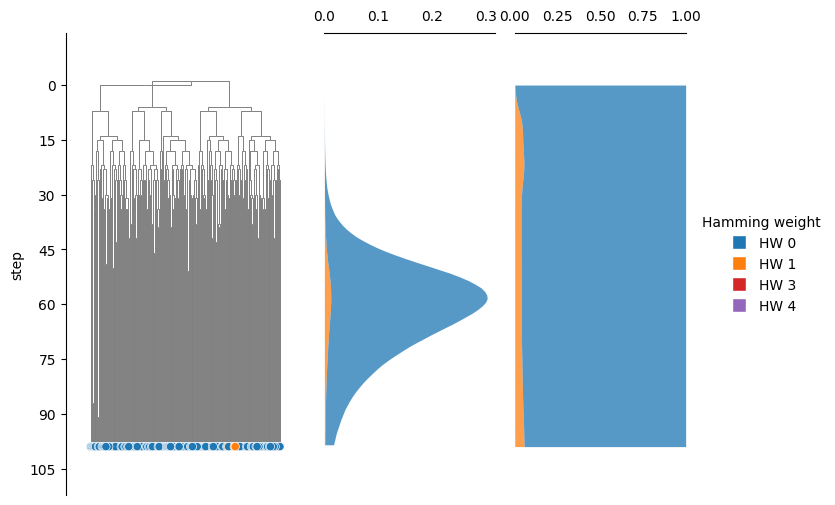

wrote trajectory parquet (300 rows): outdata/2026-05-03-allele-abm-strain-curves/a=traj+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
wrote hw parquet (1200 rows): outdata/2026-05-03-allele-abm-strain-curves/a=hw+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
wrote strain parquet (2800 rows): outdata/2026-05-03-allele-abm-strain-curves/a=strain+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
wrote records parquet (600 rows): outdata/2026-05-03-allele-abm-strain-curves/a=records+what=2026-05-03-allele-abm-strain-curves+ext=.pqt
wrote phylogeny parquet (1196 rows): outdata/2026-05-03-allele-abm-strain-curves/a=phylo+what=2026-05-03-allele-abm-strain-curves+ext=.pqt


In [ ]:
PHYLO_MUTATION_RATE = 1e-5
POW_ = POW

nbname = pathlib.Path(__file__).stem
out_dir = pathlib.Path("outdata") / nbname
out_dir.mkdir(parents=True, exist_ok=True)

def _save_replicate(kind: str, uid: str, df) -> None:
    rep_dir = out_dir / kind / uid
    rep_dir.mkdir(parents=True, exist_ok=True)
    rep_path = rep_dir / f"a={kind}+what={nbname}+ext=.pqt"
    df.to_parquet(rep_path, index=False)
    print(f"  wrote {kind} parquet ({len(df)} rows): {rep_path}")

traj_chunks = []
hw_chunks = []
strain_chunks = []
records_chunks = []
phylo_chunks = []

for _seed in range(1, N_REPLICATES + 1):
    for PHYLO_N_SITES in (2, 3, 4):
        replicate_uid = uuid.uuid4().hex
        print(
            f"=== seed={_seed} N_SITES={PHYLO_N_SITES} "
            f"uid={replicate_uid} ===",
        )
        _phylo_df, _hw_df, _strain_df, _records_df = simulate(
            MUTATION_RATE=PHYLO_MUTATION_RATE,
            N_SITES=PHYLO_N_SITES,
            N_STEPS=N_STEPS,
            POP_SIZE=POP_SIZE,
            CONTACT_RATE=0.35,
            RECOVERY_RATE=0.1,
            WANING_RATE=0.01,
            IMMUNE_STRENGTH=0.95,
            SEED_COUNT=2,
            IMMUNITY_FLOOR=0.05,
            IMMUNITY_CEILING=1.0,
            seed=_seed,
            track_phylogeny=True,
            N_SAMPLE=200,
            pow=POW_,
        )
        print(f"  snapshot rows: {len(_records_df)}")

        _params = {
            "replicate_uid": replicate_uid,
            "seed": _seed,
            "n_sites": PHYLO_N_SITES,
            "pop_size": POP_SIZE,
            "n_steps": N_STEPS,
            "engine": ENGINE,
            "pow": POW_,
        }
        _traj_stamped = _phylo_df.assign(**_params)
        _hw_stamped = _hw_df.assign(**_params)
        _strain_stamped = _strain_df.assign(**_params)
        traj_chunks.append(_traj_stamped)
        hw_chunks.append(_hw_stamped)
        strain_chunks.append(_strain_stamped)
        _save_replicate("traj", replicate_uid, _traj_stamped)
        _save_replicate("hw", replicate_uid, _hw_stamped)
        _save_replicate("strain", replicate_uid, _strain_stamped)

        _records_stamped = _records_df.assign(**_params)
        records_chunks.append(_records_stamped)
        _save_replicate("records", replicate_uid, _records_stamped)

        if SKIP_PLOTTING:
            print("  (SKIP_PLOTTING=True — skipping strain curves)")
        else:
            for palette in "tab10", "tab20", "rocket_r":
                make_strain_curves_plot(
                    PHYLO_N_SITES,
                    _phylo_df,
                    _strain_df,
                    palette=palette,
                    teeplot_outattrs={
                        "a": "strain-curves",
                        "n_sites": PHYLO_N_SITES,
                        "n_steps": int(_phylo_df["Step"].max()) + 1,
                        "replicate": _seed,
                        "palette": palette,
                        "pow": POW_,
                    },
                )

        if len(_records_df) == 0:
            print("  (no infected hosts --- skipping plot)")
            del _phylo_df, _hw_df, _strain_df, _records_df
            gc.collect()
            continue

        print(f"  extant rows: {int(_records_df['extant'].sum())}")
        for palette in "rocket_r", "tab20", "tab10":
            if SKIP_PLOTTING:
                print("  (SKIP_PLOTTING=True — skipping strain graph)")
            else:
                make_strain_graph_plot(
                    PHYLO_N_SITES,
                    _records_df,
                    max_n=4,
                    palette=palette,
                    teeplot_outattrs={
                        "a": "strain-graph",
                        "n_sites": PHYLO_N_SITES,
                        "n_steps": int(_phylo_df["Step"].max()) + 1,
                        "replicate": _seed,
                        "palette": palette,
                        "pow": POW_,
                    },
                )
        _phylogeny_df = reconstruct_phylogeny(_records_df)
        del _records_df
        gc.collect()
        print(f"  reconstructed: {len(_phylogeny_df)} nodes")
        print(f"  extant tips: {int(_phylogeny_df['extant'].sum())}")

        _phylo_stamped = _phylogeny_df.assign(**_params)
        phylo_chunks.append(_phylo_stamped)
        _save_replicate("phylo", replicate_uid, _phylo_stamped)

        for palette in "rocket_r", "tab20", "tab10":
            if SKIP_PLOTTING:
                print("  (SKIP_PLOTTING=True — skipping plot)")
            else:
                make_phylogeny_plot(
                    PHYLO_N_SITES,
                    _phylo_df,
                    _hw_df,
                    _phylogeny_df,
                    seed=_seed,
                    palette=palette,
                    teeplot_outattrs={
                        "n_sites": PHYLO_N_SITES,
                        "n_steps": int(_phylo_df["Step"].max()) + 1,
                        "replicate": _seed,
                        "palette": palette,
                        "method": "hstrat-surface",
                        "pow": POW_,
                    },
                )
        del _phylo_df, _hw_df, _strain_df, _phylogeny_df
        gc.collect()

traj_df_all = (
    pd.concat(traj_chunks, ignore_index=True)
    if traj_chunks
    else pd.DataFrame()
)
hw_df_all = (
    pd.concat(hw_chunks, ignore_index=True)
    if hw_chunks
    else pd.DataFrame()
)
strain_df_all = (
    pd.concat(strain_chunks, ignore_index=True)
    if strain_chunks
    else pd.DataFrame()
)
records_df_all = (
    pd.concat(records_chunks, ignore_index=True)
    if records_chunks
    else pd.DataFrame()
)
phylo_df_all = (
    pd.concat(phylo_chunks, ignore_index=True)
    if phylo_chunks
    else pd.DataFrame()
)

traj_path = out_dir / f"a=traj+what={nbname}+ext=.pqt"
hw_path = out_dir / f"a=hw+what={nbname}+ext=.pqt"
strain_path = out_dir / f"a=strain+what={nbname}+ext=.pqt"
records_path = out_dir / f"a=records+what={nbname}+ext=.pqt"
phylo_path = out_dir / f"a=phylo+what={nbname}+ext=.pqt"
traj_df_all.to_parquet(traj_path, index=False)
hw_df_all.to_parquet(hw_path, index=False)
strain_df_all.to_parquet(strain_path, index=False)
records_df_all.to_parquet(records_path, index=False)
phylo_df_all.to_parquet(phylo_path, index=False)
print(f"wrote trajectory parquet ({len(traj_df_all)} rows): {traj_path}")
print(f"wrote hw parquet ({len(hw_df_all)} rows): {hw_path}")
print(f"wrote strain parquet ({len(strain_df_all)} rows): {strain_path}")
print(
    f"wrote records parquet ({len(records_df_all)} rows): {records_path}"
)
print(f"wrote phylogeny parquet ({len(phylo_df_all)} rows): {phylo_path}")